# Image Enhancer + UNet Training for Optic Disc/Cup Segmentation

This notebook implements a two-phase training approach:
- **Phase 1**: Train lightweight enhancer only (UNet frozen)
- **Phase 2**: Fine-tune both enhancer and UNet jointly

The enhancer is a shallow encoder-decoder network (3-4 levels) that preprocesses images before segmentation.

## 1. Setup and Imports

In [1]:
import sys
from pathlib import Path
import torch
import matplotlib.pyplot as plt
import json

# Add src to path
project_root = Path.cwd().parent
sys.path.append(str(project_root / 'src'))

from training.train_enhancer import train_enhancer_model, plot_training_history
from data_loader.dataset import GlaucomaDataset

print(f"Project root: {project_root}")
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"CUDA device: {torch.cuda.get_device_name(0)}")


Project root: /home/robolab/dev/CAP5410-roi-enhancer-odoc
PyTorch version: 2.8.0+cu128
CUDA available: True
CUDA device: NVIDIA GeForce RTX 2080 Ti


## 2. Configuration

In [2]:
# Training hyperparameters for Image Enhancer + UNet
config = {
    'root_dir': str(project_root),
    'unet_checkpoint': str(project_root / 'checkpoints' / 'best_model.pth'),
    'num_epochs_phase1': 30,  # Train enhancer only
    'num_epochs_phase2': 20,  # Fine-tune both
    'batch_size': 16,
    'learning_rate_phase1': 1e-4,
    'learning_rate_phase2': 1e-5,  # Lower LR for fine-tuning
    'image_size': 256,
    'enhancer_base_channels': 32,
    'enhancer_levels': 3,  # 3 or 4
    'unet_base_channels': 64,
    'num_workers': 0,
    'save_dir': str(project_root / 'checkpoints_enhancer'),
    'filter_incomplete': True,
    'use_clahe': False,  # NO CLAHE - use original images
    'l1_weight': 0.001,  # Weight for L1 regularization
    'patience': 10
}

print("Image Enhancer + UNet Training Configuration:")
print("=" * 70)
for key, value in config.items():
    print(f"{key:25s}: {value}")
print("=" * 70)
print("\nTwo-Phase Training:")
print("  Phase 1: Train enhancer only (UNet frozen)")
print("  Phase 2: Fine-tune both enhancer and UNet jointly")

Image Enhancer + UNet Training Configuration:
root_dir                 : /home/robolab/dev/CAP5410-roi-enhancer-odoc
unet_checkpoint          : /home/robolab/dev/CAP5410-roi-enhancer-odoc/checkpoints/best_model.pth
num_epochs_phase1        : 30
num_epochs_phase2        : 20
batch_size               : 16
learning_rate_phase1     : 0.0001
learning_rate_phase2     : 1e-05
image_size               : 256
enhancer_base_channels   : 32
enhancer_levels          : 3
unet_base_channels       : 64
num_workers              : 0
save_dir                 : /home/robolab/dev/CAP5410-roi-enhancer-odoc/checkpoints_enhancer
filter_incomplete        : True
use_clahe                : False
l1_weight                : 0.001
patience                 : 10

Two-Phase Training:
  Phase 1: Train enhancer only (UNet frozen)
  Phase 2: Fine-tune both enhancer and UNet jointly


## 3. Train the Model


In [3]:
# Clear the dataset cache before training
GlaucomaDataset._split_cache.clear()

# Train the Image Enhancer + UNet model
model, history_phase1, history_phase2 = train_enhancer_model(**config)

Using device: cuda
Random seeds set to 42 for reproducible training

Loading datasets...
Filtering incomplete masks...
  Filtered out 234 images with incomplete masks
TRAIN split: 1845 samples
VAL split: 395 samples
TEST split: 396 samples

Loading pretrained UNet from: /home/robolab/dev/CAP5410-roi-enhancer-odoc/checkpoints/best_model.pth
✓ Loaded UNet (epoch 99)

Creating Image Enhancer...
✓ Enhancer parameters: 949,475
✓ UNet parameters: 31,043,651

PHASE 1: Training Enhancer (UNet Frozen)

phase1_Epoch 1/30
--------------------------------------------------------------------------------


Validation: 100%|██████████| 25/25 [00:05<00:00,  4.60it/s, loss=0.1654, seg=0.1653, l1=0.0853, iou_cup=0.7616]



Epoch 1 Summary:
  Train - Loss: 0.1561 (Seg: 0.1560, L1: 0.0963)
  Train - IoU: BG=0.8879, Disc=0.8427, Cup=0.7908
  Val   - Loss: 0.1552 (Seg: 0.1551, L1: 0.0871)
  Val   - IoU: BG=0.8865, Disc=0.8490, Cup=0.7803
  ✓ Saved best model (val_loss: 0.1552)

phase1_Epoch 2/30
--------------------------------------------------------------------------------


Validation: 100%|██████████| 25/25 [00:05<00:00,  4.58it/s, loss=0.1610, seg=0.1610, l1=0.0705, iou_cup=0.7681]



Epoch 2 Summary:
  Train - Loss: 0.1559 (Seg: 0.1558, L1: 0.0889)
  Train - IoU: BG=0.8881, Disc=0.8427, Cup=0.7903
  Val   - Loss: 0.1546 (Seg: 0.1546, L1: 0.0700)
  Val   - IoU: BG=0.8873, Disc=0.8506, Cup=0.7818
  ✓ Saved best model (val_loss: 0.1546)

phase1_Epoch 3/30
--------------------------------------------------------------------------------


...


Epoch 18 Summary:
  Train - Loss: 0.1557 (Seg: 0.1557, L1: 0.0613)
  Train - IoU: BG=0.8892, Disc=0.8432, Cup=0.7892
  Val   - Loss: 0.1537 (Seg: 0.1536, L1: 0.0435)
  Val   - IoU: BG=0.8882, Disc=0.8504, Cup=0.7825
  Patience: 2/10

phase2_Epoch 19/20
--------------------------------------------------------------------------------


Validation: 100%|██████████| 25/25 [00:05<00:00,  4.52it/s, loss=0.1557, seg=0.1557, l1=0.0455, iou_cup=0.7756]



Epoch 19 Summary:
  Train - Loss: 0.1566 (Seg: 0.1566, L1: 0.0615)
  Train - IoU: BG=0.8885, Disc=0.8423, Cup=0.7883
  Val   - Loss: 0.1516 (Seg: 0.1515, L1: 0.0438)
  Val   - IoU: BG=0.8890, Disc=0.8525, Cup=0.7865
  ✓ Saved best model (val_loss: 0.1516)

phase2_Epoch 20/20
--------------------------------------------------------------------------------


Validation: 100%|██████████| 25/25 [00:05<00:00,  4.54it/s, loss=0.1633, seg=0.1633, l1=0.0457, iou_cup=0.7683]



Epoch 20 Summary:
  Train - Loss: 0.1555 (Seg: 0.1555, L1: 0.0611)
  Train - IoU: BG=0.8868, Disc=0.8433, Cup=0.7910
  Val   - Loss: 0.1545 (Seg: 0.1545, L1: 0.0439)
  Val   - IoU: BG=0.8862, Disc=0.8528, Cup=0.7848
  Patience: 1/10
  ✓ Saved checkpoint

Training completed!
Phase 2 best validation loss: 0.1516


In [4]:
# Save histories as JSON
results_dir = project_root / 'results'
results_dir.mkdir(exist_ok=True, parents=True)

history_path1 = results_dir / 'enhancer_phase1_history.json'
with open(history_path1, 'w') as f:
    json.dump(history_phase1, f, indent=2)
print(f"Phase 1 history saved to: {history_path1}")

history_path2 = results_dir / 'enhancer_phase2_history.json'
with open(history_path2, 'w') as f:
    json.dump(history_phase2, f, indent=2)
print(f"Phase 2 history saved to: {history_path2}")

Phase 1 history saved to: /home/robolab/dev/CAP5410-roi-enhancer-odoc/results/enhancer_phase1_history.json
Phase 2 history saved to: /home/robolab/dev/CAP5410-roi-enhancer-odoc/results/enhancer_phase2_history.json


## 4. Visualize Training Progress

Training history saved to /home/robolab/dev/CAP5410-roi-enhancer-odoc/results/enhancer_phase1_history.png


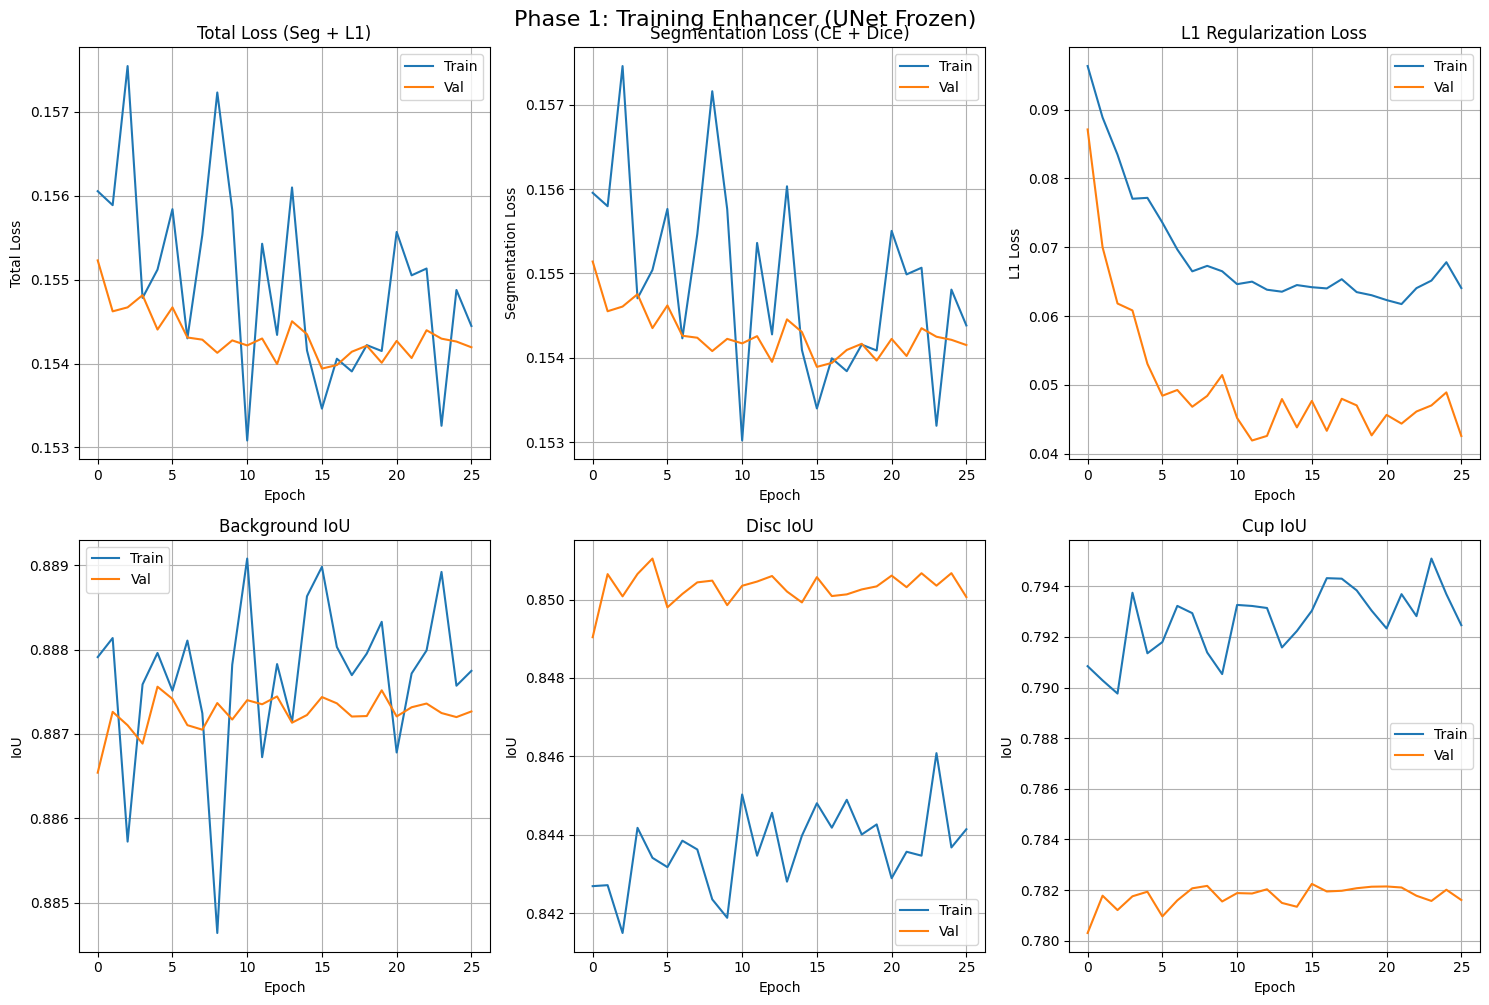

In [5]:
# Create results directory
results_dir = project_root / 'results'
results_dir.mkdir(exist_ok=True, parents=True)

# Plot Phase 1 history
fig1 = plot_training_history(
    history_phase1,
    save_path=str(results_dir / 'enhancer_phase1_history.png')
)
plt.suptitle('Phase 1: Training Enhancer (UNet Frozen)', fontsize=16, y=1.00)
plt.show()

# Plot Phase 2 history
fig2 = plot_training_history(
    history_phase2,
    save_path=str(results_dir / 'enhancer_phase2_history.png')
)
plt.suptitle('Phase 2: Joint Fine-tuning (Enhancer + UNet)', fontsize=16, y=1.00)
plt.show()

In [6]:
## 5. Print Final Metrics

In [ ]:
print("\n" + "=" * 80)
print("FINAL TRAINING RESULTS - Image Enhancer + UNet")
print("=" * 80)

print("\n=== PHASE 1 (Enhancer Only) ===")
print(f"Total Epochs: {len(history_phase1['train_loss'])}")
print("\nFinal Validation Metrics:")
print(f"  Loss:        {history_phase1['val_loss'][-1]:.4f}")
print(f"  Seg Loss:    {history_phase1['val_seg_loss'][-1]:.4f}")
print(f"  L1 Loss:     {history_phase1['val_l1_loss'][-1]:.4f}")
print(f"  IoU (Cup):   {history_phase1['val_iou_cup'][-1]:.4f}")

print("\n=== PHASE 2 (Joint Fine-tuning) ===")
print(f"Total Epochs: {len(history_phase2['train_loss'])}")
print("\nFinal Validation Metrics:")
print(f"  Loss:        {history_phase2['val_loss'][-1]:.4f}")
print(f"  Seg Loss:    {history_phase2['val_seg_loss'][-1]:.4f}")
print(f"  L1 Loss:     {history_phase2['val_l1_loss'][-1]:.4f}")
print(f"  IoU (Cup):   {history_phase2['val_iou_cup'][-1]:.4f}")

print("\nBest Validation Loss (Phase 2):")
best_epoch = history_phase2['val_loss'].index(min(history_phase2['val_loss'])) + 1
best_val_loss = min(history_phase2['val_loss'])
print(f"  Epoch: {best_epoch}")
print(f"  Loss:  {best_val_loss:.4f}")

print("\n" + "=" * 80)


FINAL TRAINING RESULTS - Image Enhancer + UNet

=== PHASE 1 (Enhancer Only) ===
Total Epochs: 26

Final Validation Metrics:
  Loss:        0.1542
  Seg Loss:    0.1542
  L1 Loss:     0.0426
  IoU (Cup):   0.7816

=== PHASE 2 (Joint Fine-tuning) ===
Total Epochs: 20

Final Validation Metrics:
  Loss:        0.1545
  Seg Loss:    0.1545
  L1 Loss:     0.0439
  IoU (Cup):   0.7848

Best Validation Loss (Phase 2):
  Epoch: 19
  Loss:  0.1516



: 

# Save histories as JSON
history_path1 = results_dir / 'enhancer_phase1_history.json'
with open(history_path1, 'w') as f:
    json.dump(history_phase1, f, indent=2)
print(f"Phase 1 history saved to: {history_path1}")

history_path2 = results_dir / 'enhancer_phase2_history.json'
with open(history_path2, 'w') as f:
    json.dump(history_phase2, f, indent=2)
print(f"Phase 2 history saved to: {history_path2}")